# Blood vs Stool Virulence

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data
metadata_file = "/Users/davidabelson/Library/CloudStorage/OneDrive-UniversityofCambridge/Aaron Weimann's files - project_k/data/final/metadata/metadata_final_curated_slimmed.tsv"
metadata = pd.read_csv(metadata_file, sep="\t")

/var/folders/wn/jcfcy14j4232dygbwnnqz6hw0000gn/T/ipykernel_44395/495702727.py:10: DtypeWarning: Columns (15,128,131,133,147,148,149,150,151) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_file, sep="\t")


Overall number of blood and stool: isolation_source_category
blood                    13435
faeces & rectal swabs    12901
Name: count, dtype: int64
Total number of blood and stool: 26336
Overall proportion of blood and stool: isolation_source_category
blood                    0.510138
faeces & rectal swabs    0.489862
Name: proportion, dtype: float64


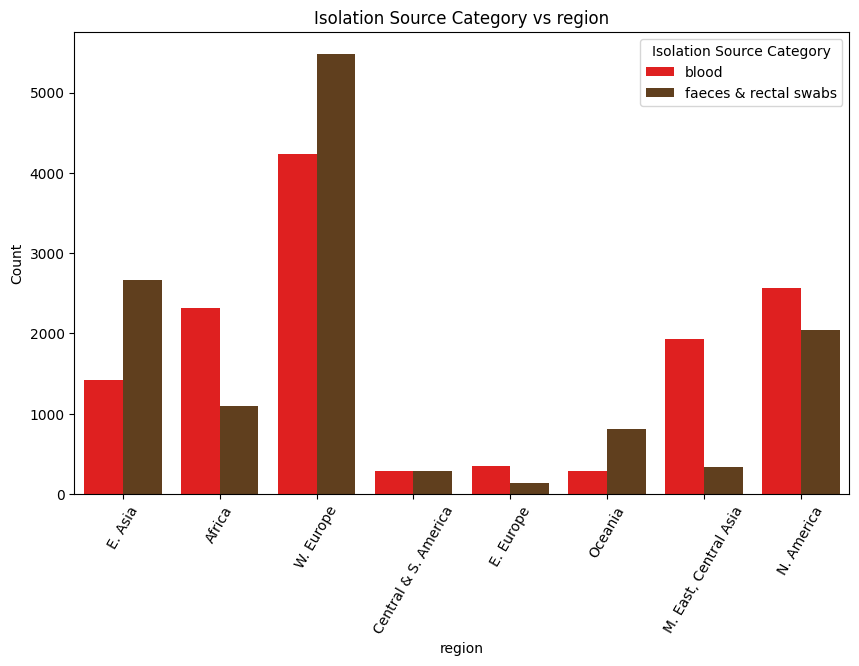

In [2]:
# blood v stool, isolation_source_category
blood_vs_stool_df = metadata[metadata['isolation_source_category'].isin(['blood', 'faeces & rectal swabs'])]

def plot_blood_vs_stool_breakdown(blood_vs_stool_df, x_axis = 'region'):
      # Overall proportion of blood and stool - print
      print(f"Overall number of blood and stool: {blood_vs_stool_df['isolation_source_category'].value_counts()}")
      # The total number of blood and stool
      total_bvs = blood_vs_stool_df['isolation_source_category'].value_counts().sum()
      print(f"Total number of blood and stool: {total_bvs}")
      # The proportion of blood and stool
      print(f"Overall proportion of blood and stool: {blood_vs_stool_df['isolation_source_category'].value_counts(normalize=True)}")

      # Define color palette: blood as red, faeces & rectal swabs as brown
      palette = {'blood': 'red', 'faeces & rectal swabs': '#6B3F13'}  # dark brown

      # Plot histogram of isolation source category vs country
      plt.figure(figsize=(10, 6))
      sns.countplot(
            data=blood_vs_stool_df, 
            x=x_axis, 
            hue='isolation_source_category',
            palette=palette
      )
      plt.title(f'Isolation Source Category vs {x_axis}')
      plt.xlabel(x_axis)
      plt.xticks(rotation=60)
      plt.ylabel('Count')
      plt.legend(title='Isolation Source Category')
      plt.show()

plot_blood_vs_stool_breakdown(blood_vs_stool_df, 'region')


Minimum counts per region (to sample from both groups):
Africa                   1100
Central & S. America      281
E. Asia                  1419
E. Europe                 132
M. East, Central Asia     342
N. America               2041
Oceania                   287
W. Europe                4231
dtype: int64

Total sampled: 19666 samples

Sampled counts per region:
region                 isolation_source_category
Africa                 blood                        1100
                       faeces & rectal swabs        1100
Central & S. America   blood                         281
                       faeces & rectal swabs         281
E. Asia                blood                        1419
                       faeces & rectal swabs        1419
E. Europe              blood                         132
                       faeces & rectal swabs         132
M. East, Central Asia  blood                         342
                       faeces & rectal swabs         342
N. America   

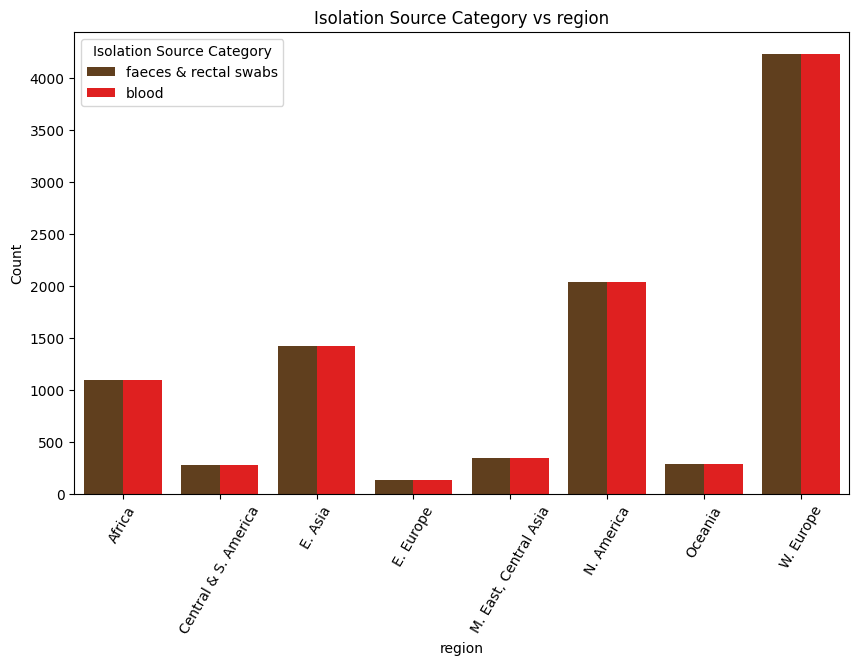

In [3]:
def stratified_sampling(df, variable_to_stratify = 'region'):
    # Sample blood and stool evenly, stratified by region
    # Get the number of stool samples per region
    
    stool_counts = df[df['isolation_source_category'] == 'faeces & rectal swabs'].groupby('region').size()
    #print("Stool counts per region:")
    #print(stool_counts)
    # Get the number of blood samples per region
    blood_counts = df[df['isolation_source_category'] == 'blood'].groupby('region').size()
    #print("\nBlood counts per region:")
    #print(blood_counts)

    # Align the Series and take the minimum for each region
    # Only keep regions that have both stool and blood samples
    common_regions = stool_counts.index.intersection(blood_counts.index)
    min_counts = pd.Series({
        region: min(stool_counts[region], blood_counts[region]) 
        for region in common_regions
    })
    print("\nMinimum counts per region (to sample from both groups):")
    print(min_counts)

    # Randomly sample the minimum count from both groups for each region
    sampled_df = pd.DataFrame()

    for region in common_regions:
        n_samples = min_counts[region]
        
        # Sample from stool
        stool_region = df[(df['isolation_source_category'] == 'faeces & rectal swabs') & (df[variable_to_stratify] == region)]
        sampled_stool = stool_region.sample(n=min(n_samples, len(stool_region)), random_state=42)
        
        # Sample from blood
        blood_region = df[(df['isolation_source_category'] == 'blood') & (df[variable_to_stratify] == region)]
        sampled_blood = blood_region.sample(n=min(n_samples, len(blood_region)), random_state=42)
        
        # Combine
        sampled_df = pd.concat([sampled_df, sampled_stool, sampled_blood], ignore_index=True)

    print(f"\nTotal sampled: {len(sampled_df)} samples")
    print(f"\nSampled counts per {variable_to_stratify}:")
    print(sampled_df.groupby([variable_to_stratify, 'isolation_source_category']).size())
    # Return the sampled dataframe
    return sampled_df

# Sample blood and stool evenly, stratified by region
sample_by_region_df = stratified_sampling(blood_vs_stool_df, 'region')

# Plot the histogram of isolation source category vs region
plot_blood_vs_stool_breakdown(sample_by_region_df, 'region')

Overall number of blood and stool: isolation_source_category
faeces & rectal swabs    9833
blood                    9833
Name: count, dtype: int64
Total number of blood and stool: 19666
Overall proportion of blood and stool: isolation_source_category
faeces & rectal swabs    0.5
blood                    0.5
Name: proportion, dtype: float64


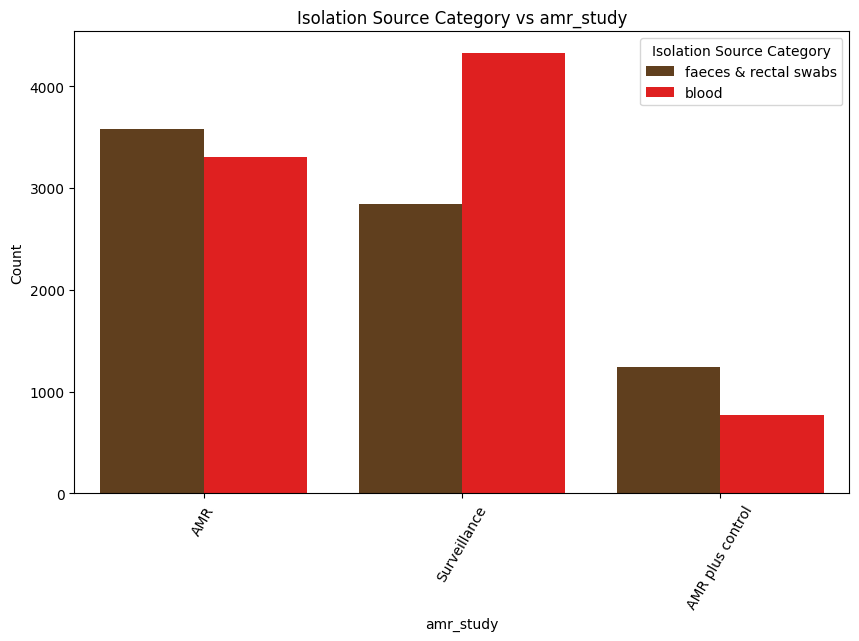

In [4]:
# Next lets look at sampled_bvs by amr_study type, look in full set
plot_blood_vs_stool_breakdown(sample_by_region_df, 'amr_study')


Overall number of blood and stool: isolation_source_category
faeces & rectal swabs    9833
blood                    9833
Name: count, dtype: int64
Total number of blood and stool: 19666
Overall proportion of blood and stool: isolation_source_category
faeces & rectal swabs    0.5
blood                    0.5
Name: proportion, dtype: float64


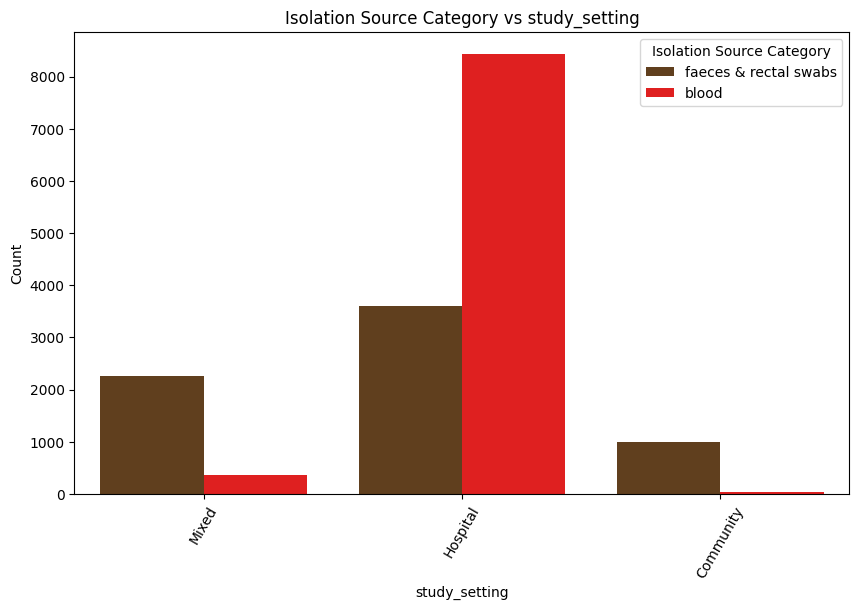

In [5]:
plot_blood_vs_stool_breakdown(sample_by_region_df, 'study_setting')

In [6]:
# Lets limit to study_setting = 'Hospital' and host = "human" and study_type = "AMR"
final_set = sample_by_region_df[(sample_by_region_df['study_setting'] == 'Hospital') & ((sample_by_region_df['amr_study'] == "AMR") | (sample_by_region_df['amr_study'] == "AMR plus control"))]

# What is the breakdown of 'host_category' in this subset?
final_set['host_category'].value_counts()

# # What is the breakdown of 'isolation_source_category' in this subset?
# bvs_hospital['isolation_source_category'].value_counts()



host_category
human                   7086
clinical environment      11
None (unhelpful)           8
grazing livestock          1
Name: count, dtype: int64

Overall number of blood and stool: isolation_source_category
blood                    3856
faeces & rectal swabs    3470
Name: count, dtype: int64
Total number of blood and stool: 7326
Overall proportion of blood and stool: isolation_source_category
blood                    0.526345
faeces & rectal swabs    0.473655
Name: proportion, dtype: float64


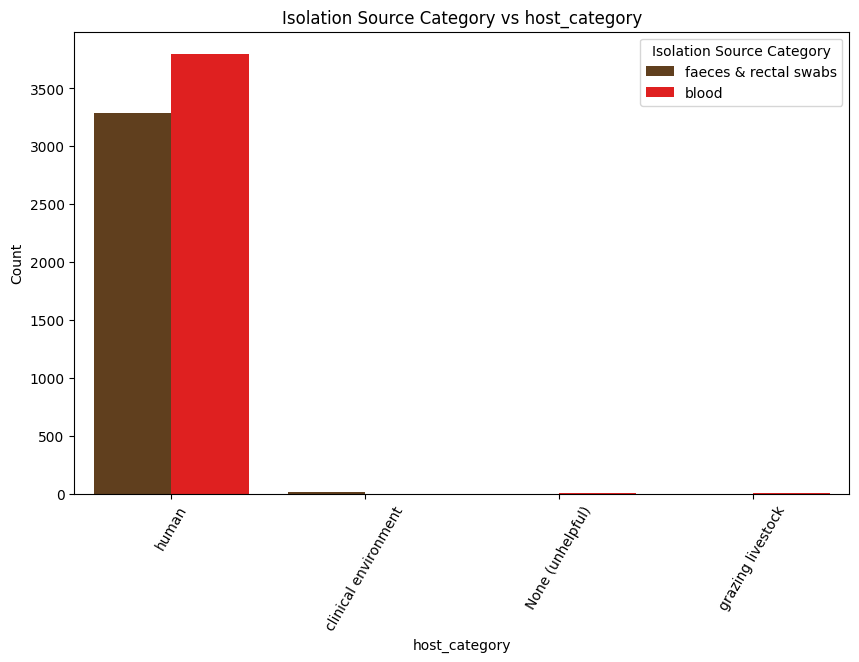

In [7]:
plot_blood_vs_stool_breakdown(final_set, 'host_category')


